# **Overview**

This is a transactional data set which contains all the transactions occurring between **01/12/2010** and **09/12/2011** for a **UK-based and registered non-store online retail.** Many customers of the company are wholesalers.

------------------

### **Data Dictionary**

* **InvoiceNo:** a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
* **StockCode:** a 5-digit integral number uniquely assigned to each distinct product.
* **Description:** product name.
* **Quantity:** the quantities of each product (item) per transaction.
* **InvoiceDate:** the day and time when each transaction was generated.
* **UnitPrice:** product price per unit (sterling).
* **CustomerID:** a 5-digit integral number uniquely assigned to each customer.
* **Country:** the name of the country where each customer resides.


--------------

### **Import Liberaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Loading Dataset

In [2]:
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### 1.Data Cleaning

In [3]:
df.shape

(541909, 8)

Our Dataset consists of `541909` data samples and `8` feature columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


* Data points look good with no missing values except for the `CustomerID` and `Description` columns.

#### 1.1 Check Duplicate Values

In [5]:
df.duplicated().sum()

5268

In [6]:
# Dropping Duplicated values
df = df.drop_duplicates()

#### 1.2 Check Missing Values

In [7]:
missing = df[['CustomerID','Description']].isna().sum()
missing

CustomerID     135037
Description      1454
dtype: int64

In [8]:
ratio = missing / len(df) *100
ratio

CustomerID     25.163377
Description     0.270945
dtype: float64

* `CustomerID` missing values make `25%` of our Dataset, so we will choose to leave it and replace the `NaN` value with `Unknown`.
* `Description` missing values make `0.27%` of our Dataset, we also going to keep it and replace the `NaN` values with `Not Available`.

In [9]:
missing_val = df['CustomerID'].isna()
df[missing_val].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [10]:
df['CustomerID'] = df['CustomerID'].fillna('Unknown')
df['Description'] = df['Description'].fillna('Not Available')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536641 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   536641 non-null  object        
 7   Country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 36.8+ MB


#### 1.3 Date Format

* We will remove the hour from the `InvoiceDate` for a cleaner view.

In [12]:
df['InvoiceDate'] = df['InvoiceDate'].dt.normalize()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom


-------------

### 2. Exploratory Data Analysis (EDA)

* First we will add another column featuring **`Total Sales`**. 

In [13]:
df['Total Sales'] = df['Quantity'] * df['UnitPrice']

In [14]:
df[['Quantity','UnitPrice','Total Sales']].describe()

,Quantity,UnitPrice,Total Sales
count,536641.000000,536641.000000,536641.000000
mean,9.620029,4.632656,18.123861
std,219.130156,97.233118,380.656263
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.870000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


* There are orders with negative values in `Quantity` and `UnitPrice`, we don't know exactly whether these orders were cancelled or refunded, but since they are recorded in negative, we will make the assumption that they are refunded.

#### 2.1 Negative Quantity

In [15]:
cancelled = df['Quantity'] < 1
df[cancelled]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Sales
141,C536379,D,Discount,-1,2010-12-01,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01,0.29,17548.0,United Kingdom,-6.96
...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09,0.83,14397.0,United Kingdom,-9.13
541541,C581499,M,Manual,-1,2011-12-09,224.69,15498.0,United Kingdom,-224.69
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09,10.95,15311.0,United Kingdom,-54.75
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09,1.25,17315.0,United Kingdom,-1.25


In [16]:
cancellation_ratio = len(df[cancelled]) / len(df) *100
cancellation_ratio

1.9728272718633126

* There are **`10587`** refunded orders responsible for almost **`2%`** of total orders, which is a very low percetange that indicates quality and reliability.

#### 2.2 Outliers

<Axes: ylabel='Quantity'>

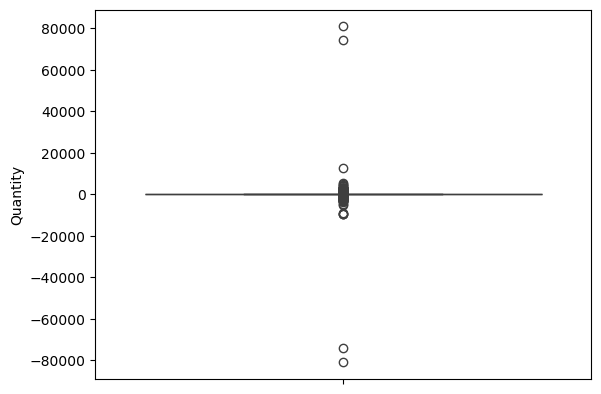

In [17]:
sns.boxplot(df['Quantity'])

* We can see that `75%` of orders' `Quantity` are between `1` item and `10` items.

In [18]:
# Calculating upper outlier limit

Q1 = 1
Q3 = 10
IQR = Q3 -Q1
upper_limit = Q3 + 1.5*IQR

outliers = df['Quantity'] > upper_limit
df[outliers]['Quantity'].value_counts()

Quantity
24       23961
48        6057
25        5105
36        3811
72        1946
         ...  
3186         1
1394         1
261          1
142          1
80995        1
Name: count, Length: 370, dtype: int64

* There are **`370`** different values for **`Quantity`** that we would consider outliers to our data ranging from **`24`** items/order to **`80995`** items/order which is avery wide range.

----------

### 3. Sales and Revenue Performance

* We will conduct a **Time Series Analysis** to see how **Sales** trends over time.

#### 3.1 Monthly Sales

In [19]:
#df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [20]:
monthly_sales = df.set_index('InvoiceDate').resample('M')['Total Sales'].sum()
monthly_sales                           

InvoiceDate
2010-12-31     746723.610
2011-01-31     558448.560
2011-02-28     497026.410
2011-03-31     682013.980
2011-04-30     492367.841
2011-05-31     722094.100
2011-06-30     689977.230
2011-07-31     680156.991
2011-08-31     681386.460
2011-09-30    1017596.682
2011-10-31    1069368.230
2011-11-30    1456145.800
2011-12-31     432701.060
Freq: M, Name: Total Sales, dtype: float64

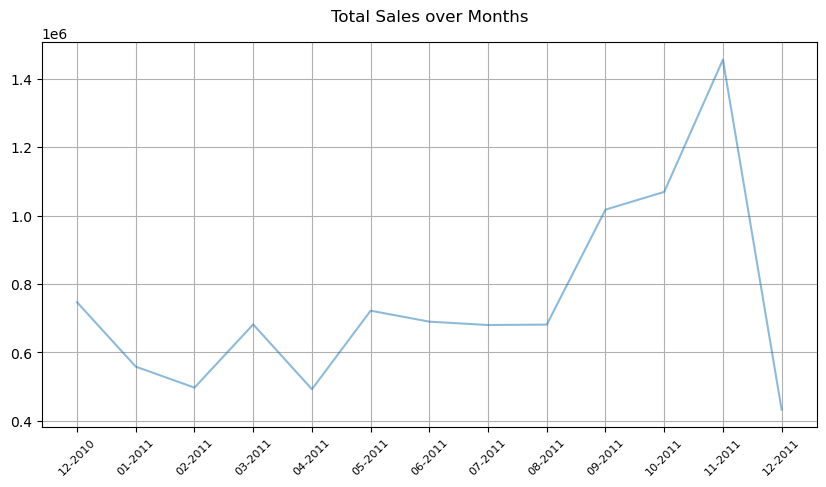

In [21]:
monthly_sales_df = pd.DataFrame(monthly_sales.values)

ax = monthly_sales_df.plot(figsize=(10,5), fontsize=10,
                        grid = True,
                        alpha = 0.5,
                        legend=False)

ax.set_xticks(range(len(monthly_sales.index)), [x.strftime('%m-%Y') for x in monthly_sales.index], rotation=45, fontsize=8)
ax.set_title('Total Sales over Months', fontsize=12, pad=15)
plt.show()


* There is a drastic drop in sales in **DEC 2011** that worth examining.

In [22]:
target_date= '2011-11-30'

dec_sales = df['InvoiceDate'] > target_date
df[dec_sales]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Sales
516384,C579889,23245,SET OF 3 REGENCY CAKE TINS,-8,2011-12-01,4.15,13853.0,United Kingdom,-33.20
516385,C579890,84947,ANTIQUE SILVER TEA GLASS ENGRAVED,-1,2011-12-01,1.25,15197.0,United Kingdom,-1.25
516386,C579890,23374,RED SPOT PAPER GIFT BAG,-1,2011-12-01,0.82,15197.0,United Kingdom,-0.82
516387,C579890,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,-2,2011-12-01,0.85,15197.0,United Kingdom,-1.70
516388,C579891,23485,BOTANICAL GARDENS WALL CLOCK,-1,2011-12-01,25.00,13644.0,United Kingdom,-25.00
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.0,France,16.60


In [23]:
print('Min Date in December :', df[dec_sales]['InvoiceDate'].min())
print('Max Date in December :', df[dec_sales]['InvoiceDate'].max())

Min Date in December : 2011-12-01 00:00:00
Max Date in December : 2011-12-09 00:00:00


* The drop we noticed in **Dec 2011** sales is due to the fact that we only have data for the first **nine** days in the month, so it would be a misinterpretation to consider these data in our analysis.

In [24]:
df = df.loc[df['InvoiceDate'] <= target_date]
df.shape

(511395, 9)

In [25]:
monthly_sales = df.set_index('InvoiceDate').resample('M')['Total Sales'].sum()
monthly_sales 

InvoiceDate
2010-12-31     746723.610
2011-01-31     558448.560
2011-02-28     497026.410
2011-03-31     682013.980
2011-04-30     492367.841
2011-05-31     722094.100
2011-06-30     689977.230
2011-07-31     680156.991
2011-08-31     681386.460
2011-09-30    1017596.682
2011-10-31    1069368.230
2011-11-30    1456145.800
Freq: M, Name: Total Sales, dtype: float64

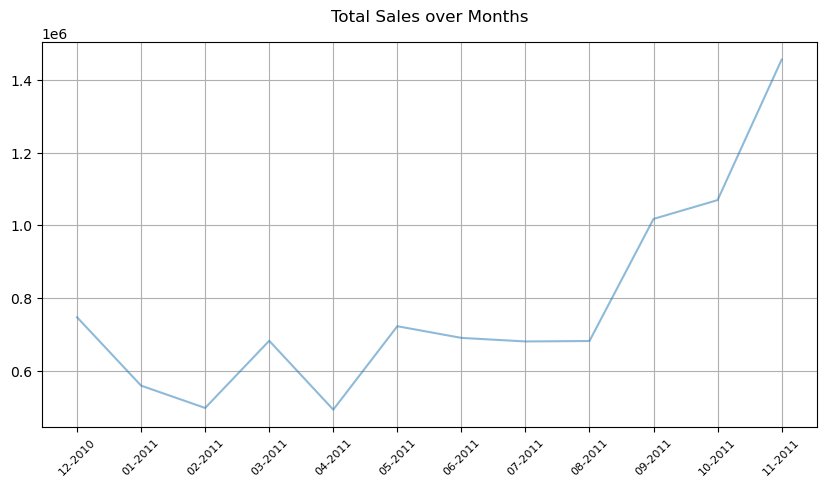

In [26]:
monthly_sales_df = pd.DataFrame(monthly_sales.values)

ax = monthly_sales_df.plot(figsize=(10,5), fontsize=10,
                        grid = True,
                        alpha = 0.5,
                        legend=False)

ax.set_xticks(range(len(monthly_sales.index)), [x.strftime('%m-%Y') for x in monthly_sales.index], rotation=45, fontsize=8)
ax.set_title('Total Sales over Months', fontsize=12, pad=15)
plt.show()

* We can see that there is a noticeable increase in sales on a monthly basis starting from **SEP 2011**, this could be due to different reasons, business growth, implementing a new marketing strategy, seasonal reasons, or any other reason. comparing this period with the same period last year could give us more insights about this phenomenon.

--------------

#### 3.2 Best-selling Products

In [27]:
best_selling = df.groupby(['StockCode','Description'])['Quantity'].sum().reset_index()
best_selling

,StockCode,Description,Quantity
0,10002,INFLATABLE POLITICAL GLOBE,860
1,10002,Not Available,177
2,10080,GROOVY CACTUS INFLATABLE,303
3,10080,Not Available,170
4,10080,check,22
...,...,...,...
5702,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7
5703,gift_0001_30,Not Available,30
5704,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3
5705,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4


In [28]:
top10_products = best_selling.sort_values(by='Quantity', ascending=False).head(10)
top10_products

,StockCode,Description,Quantity
3676,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,52384
5223,85099B,JUMBO BAG RED RETROSPOT,46170
565,21212,PACK OF 72 RETROSPOT CAKE CASES,35557
3846,84879,ASSORTED COLOUR BIRD ORNAMENT,34952
5236,85123A,WHITE HANGING HEART T-LIGHT HOLDER,34253
1557,22197,POPCORN HOLDER,30124
2664,23084,RABBIT NIGHT LIGHT,26340
1881,22492,MINI PAINT SET VINTAGE,26145
2042,22616,PACK OF 12 LONDON TISSUES,25676
1307,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24485


Text(0.5, 1.0, 'Best-Selling Products')

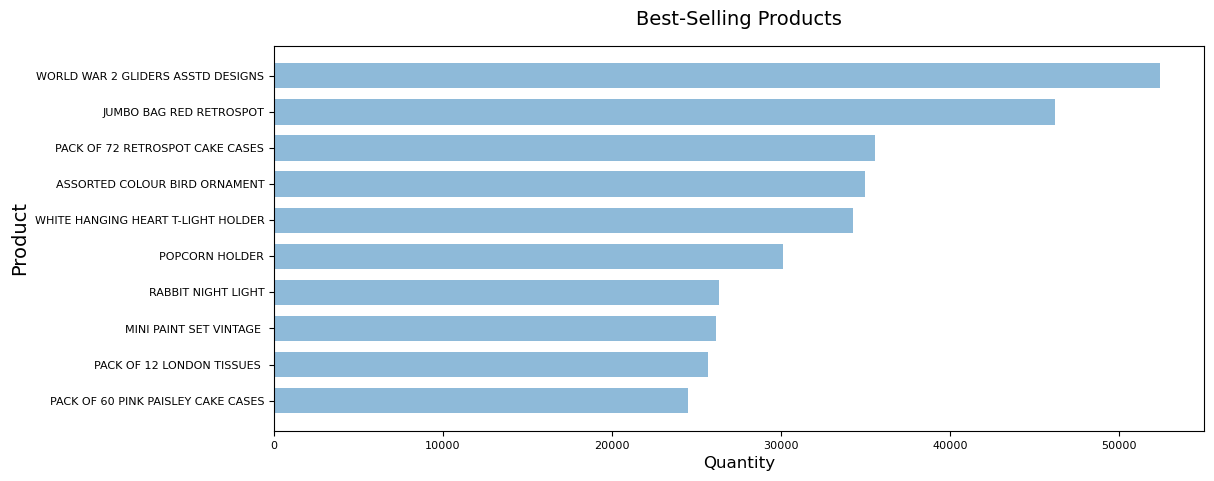

In [29]:
plt.figure(figsize=(12,5))

plt.barh(top10_products['Description'], top10_products['Quantity'],alpha=0.5, height=0.7)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel('Quantity',fontsize=12)
plt.ylabel('Product',fontsize=14)
plt.gca().invert_yaxis()
plt.title('Best-Selling Products', fontsize=14, pad=15)


* We can see that **WORLD WAR 2 GLIDERS ASSTD DESIGNS** and **JUMBO BAG RED RETROSPOT** are in high demand by a noticeable margin compared to other products.

-------------

#### 3.2 Best-Selling Products on Monthly Basis

* Let's deep dive more and find top-selling products each month.

In [30]:
top_monthly_products = df.groupby([pd.Grouper(key='InvoiceDate',freq='M'),'StockCode'])['Quantity'].sum().reset_index()
top_monthly_products

,InvoiceDate,StockCode,Quantity
0,2010-12-31,10002,251
1,2010-12-31,10120,16
2,2010-12-31,10125,154
3,2010-12-31,10133,130
4,2010-12-31,10135,411
...,...,...,...
32192,2011-11-30,DCGSSGIRL,1
32193,2011-11-30,DOT,47
32194,2011-11-30,M,3659
32195,2011-11-30,POST,1231


In [31]:
top5 = top_monthly_products.set_index('StockCode').groupby('InvoiceDate')['Quantity'].apply(lambda x: x.nlargest(5))
top5

InvoiceDate  StockCode
2010-12-31   84077         5195
             21212         4076
             22834         3356
             85123A        3225
             22197         2730
2011-01-31   37413         5568
             85123A        5516
             21212         3406
             21108         3246
             17003         3181
2011-02-28   22053         3986
             22693         3795
             84077         3518
             85099B        3078
             22616         2725
2011-03-31   85099B        5281
             21212         3974
             84077         3888
             84988         3635
             22616         3633
2011-04-30   84077        10143
             21212         2968
             22440         2644
             22693         2609
             47556B        2600
2011-05-31   22197         6840
             15036         4684
             21977         4055
             85123A        3991
             84077         3893
2011-06-30   8512

In [32]:
top5_df = pd.DataFrame(top5)
top5_df

Quantity
InvoiceDate StockCode          
2010-12-31  84077          5195
            21212          4076
            22834          3356
            85123A         3225
            22197          2730
2011-01-31  37413          5568
            85123A         5516
            21212          3406
            21108          3246
            17003          3181
2011-02-28  22053          3986
            22693          3795
            84077          3518
            85099B         3078
            22616          2725
2011-03-31  85099B         5281
            21212          3974
            84077          3888
            84988          3635
            22616          3633
2011-04-30  84077         10143
            21212          2968
            22440          2644
            22693          2609
            47556B         2600
2011-05-31  22197          6840
            15036          4684
            21977          4055
            85123A         3991
            84077          3893
2011-06-30  85123A         5657
            85099B         3676
            15036          3346
            17003          2989
            22616          2429
2011-07-31  84077          3714
            84568          3579
            23343          3177
            85099B         3126
            85123A         2999
2011-08-31  84879          6544
            22197          5416
            85099B         5301
            23203          3904
            23199          3205
2011-09-30  85099B         4265
            22197          4153
            22952          3710
            84077          3515
            22492          3337
2011-10-31  84077          8084
            23084          6344
            22197          5861
            85099B         4803
            22952          3775
2011-11-30  23084         14842
            84826         12551
            22197         12151
            22086          7858
            85099B         5806

In [33]:
top5_df_ = top5_df.reset_index()
top5_df_.set_index('InvoiceDate')

,StockCode,Quantity
InvoiceDate,,
2010-12-31,84077,5195
2010-12-31,21212,4076
2010-12-31,22834,3356
2010-12-31,85123A,3225
2010-12-31,22197,2730
2011-01-31,37413,5568
2011-01-31,85123A,5516
2011-01-31,21212,3406
2011-01-31,21108,3246


In [34]:
top5_df_['StockCode'].value_counts()

StockCode
84077     8
85099B    8
22197     6
85123A    5
21212     4
22616     3
22693     2
15036     2
22952     2
17003     2
23084     2
23343     1
22492     1
23199     1
23203     1
84826     1
84879     1
22440     1
84568     1
21977     1
47556B    1
84988     1
22053     1
21108     1
37413     1
22834     1
22086     1
Name: count, dtype: int64

In [35]:
top_products = [84077,'85099B',22197,'85123A',21212]
top_products_df = top5_df_.loc[top5_df_['StockCode'].isin(top_products)]
top_products_df.head()

,InvoiceDate,StockCode,Quantity
0,2010-12-31,84077,5195
1,2010-12-31,21212,4076
3,2010-12-31,85123A,3225
4,2010-12-31,22197,2730
6,2011-01-31,85123A,5516


In [36]:
top_products_df = top_products_df.pivot(index='InvoiceDate',columns='StockCode', values='Quantity').fillna(0)
top_products_df

StockCode,21212,22197,84077,85099B,85123A
InvoiceDate,,,,,
2010-12-31,4076.0,2730.0,5195.0,0.0,3225.0
2011-01-31,3406.0,0.0,0.0,0.0,5516.0
2011-02-28,0.0,0.0,3518.0,3078.0,0.0
2011-03-31,3974.0,0.0,3888.0,5281.0,0.0
2011-04-30,2968.0,0.0,10143.0,0.0,0.0
2011-05-31,0.0,6840.0,3893.0,0.0,3991.0
2011-06-30,0.0,0.0,0.0,3676.0,5657.0
2011-07-31,0.0,0.0,3714.0,3126.0,2999.0
2011-08-31,0.0,5416.0,0.0,5301.0,0.0


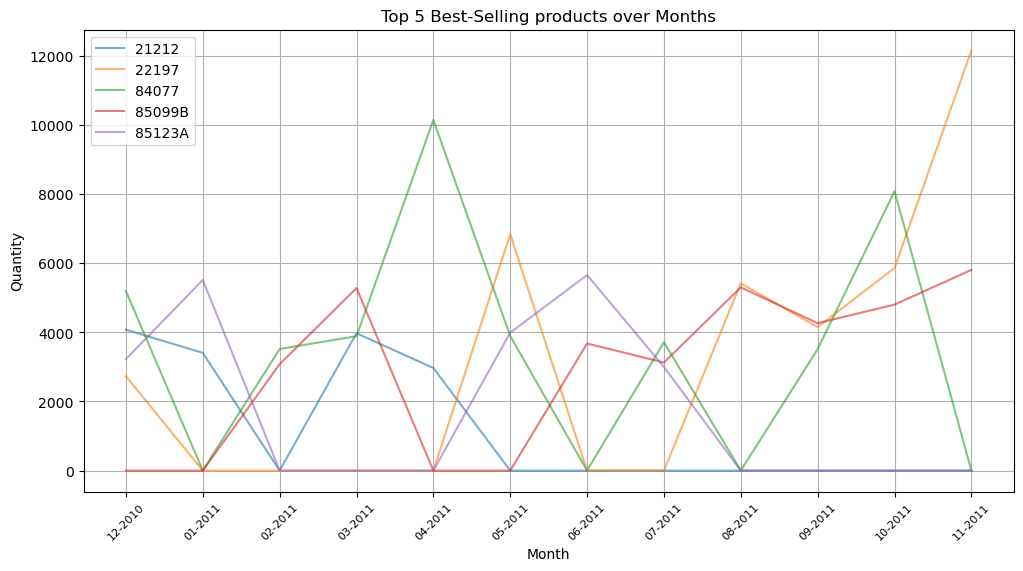

In [37]:
fig,ax = plt.subplots()

ax = pd.DataFrame(top_products_df.values).plot(ax=ax,
                          figsize=(12,6),
                          grid=True,
                          alpha=0.6                     
                         )
ax.set_xlabel('Month')
ax.set_ylabel('Quantity')
ax.legend(top_products_df.columns, loc='upper left')
ax.set_title('Top 5 Best-Selling products over Months') 
plt.xticks(range(len(top_products_df.index)), [x.strftime('%m-%Y') for x in top_products_df.index], rotation=45, fontsize=8)

plt.show()

* The sales of products with stock code **`21212`** fluctuate around **4,000** items per order until reaching zero starting **MAY-2011**.
* The sales of products with stock code **`85123A`** fluctuate around **6,000** items per order until reaching zero starting **AUG-2011**.
* The sales of products with stock code **`84077`** reached its peak in **APR-2011** with around **10,000** items per order and returned to witness another peak in **OCT-2011** with **8,000** items per order.
* The products of stock code **`85099B`** seem to have a steady sales performance with average sales of **4,500** items per order through the year of **2011**.
* The sales of products with stock code **`22197`** have an average sales of **5,000** items per order before it witnessed a spike in sales in **NOV-2011** of **12,000** items per order.

--------------

### 4. Customer insights

* In this step we will analyze our dataset to find the most valuable customers in terms of **total spendings** and **frequency of purchases**

#### 4.1 Monthly Repeated Customers

In [38]:
invoice_df = df.groupby(['InvoiceNo','InvoiceDate']).agg({'Total Sales': sum, 'CustomerID': max}).reset_index()
invoice_df.head()

,InvoiceNo,InvoiceDate,Total Sales,CustomerID
0,536365,2010-12-01,139.12,17850.0
1,536366,2010-12-01,22.20,17850.0
2,536367,2010-12-01,278.73,13047.0
3,536368,2010-12-01,70.05,13047.0
4,536369,2010-12-01,17.85,13047.0


In [39]:
rep_cust_ids = invoice_df.groupby('CustomerID')['CustomerID'].filter(lambda x: len(x) > 1).unique()
rep_cust_ids

array([17850.0, 13047.0, 12583.0, ..., 15060.0, 17820.0, 13693.0],
      dtype=object)

In [40]:
monthly_repeated_cust = invoice_df[invoice_df['CustomerID'].isin(rep_cust_ids)].set_index('InvoiceDate').resample('M')['CustomerID'].nunique()
monthly_repeated_cust

InvoiceDate
2010-12-31     832
2011-01-31     717
2011-02-28     721
2011-03-31     906
2011-04-30     818
2011-05-31    1001
2011-06-30     979
2011-07-31     922
2011-08-31     909
2011-09-30    1168
2011-10-31    1206
2011-11-30    1466
Freq: M, Name: CustomerID, dtype: int64

In [41]:
month_repeated =  invoice_df.set_index('InvoiceDate').groupby('CustomerID').filter(lambda x: len(x) > 1).resample('M')['CustomerID'].nunique()
month_repeated

InvoiceDate
2010-12-31     832
2011-01-31     717
2011-02-28     721
2011-03-31     906
2011-04-30     818
2011-05-31    1001
2011-06-30     979
2011-07-31     922
2011-08-31     909
2011-09-30    1168
2011-10-31    1206
2011-11-30    1466
Freq: M, Name: CustomerID, dtype: int64

In [42]:
monthly_unique_Cust= invoice_df.set_index('InvoiceDate').resample('M')['CustomerID'].nunique()
monthly_unique_Cust

InvoiceDate
2010-12-31     949
2011-01-31     784
2011-02-28     799
2011-03-31    1021
2011-04-30     900
2011-05-31    1080
2011-06-30    1052
2011-07-31     994
2011-08-31     981
2011-09-30    1303
2011-10-31    1426
2011-11-30    1712
Freq: M, Name: CustomerID, dtype: int64

In [43]:
# Frequent customers' contribution to overall customers
repeated_pct = monthly_repeated_cust/monthly_unique_Cust *100
repeated_pct

InvoiceDate
2010-12-31    87.671233
2011-01-31    91.454082
2011-02-28    90.237797
2011-03-31    88.736533
2011-04-30    90.888889
2011-05-31    92.685185
2011-06-30    93.060837
2011-07-31    92.756539
2011-08-31    92.660550
2011-09-30    89.639294
2011-10-31    84.572230
2011-11-30    85.630841
Freq: M, Name: CustomerID, dtype: float64

* The percentage of Repeated or Regular customers ranges from **84~91%** of total customers, and this percentage seems to be stable and consistent.
* The business will definitely benefit from a steady stream of customers.

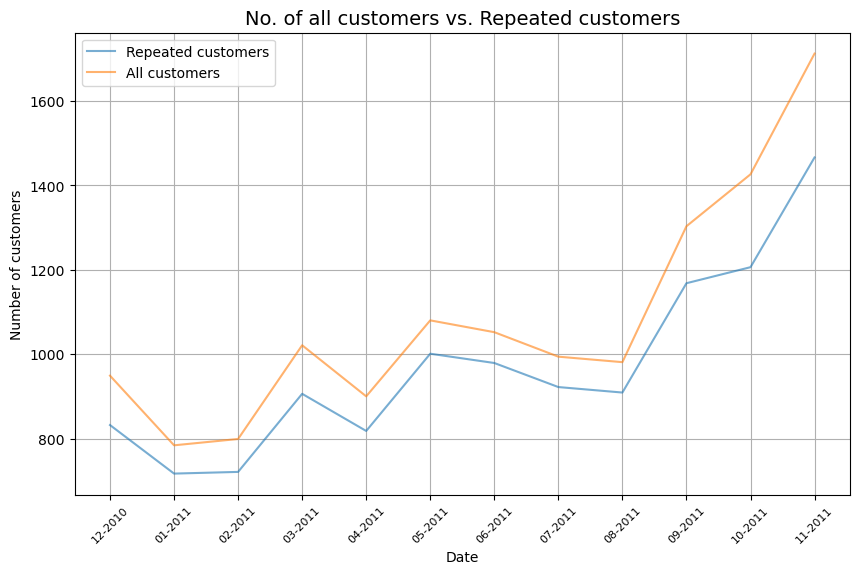

In [44]:
ax = pd.DataFrame(monthly_repeated_cust.values).plot(figsize=(10,6), grid=True, alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Number of customers')
ax.set_title('No. of all customers vs. Repeated customers', fontsize=14)

pd.DataFrame(monthly_unique_Cust.values).plot(ax=ax, alpha=0.6, grid=True)
ax.legend(['Repeated customers', 'All customers'])
ax.set_xticks(range(len(monthly_unique_Cust.index)),[x.strftime('%m-%Y') for x in monthly_unique_Cust.index],rotation=45, fontsize=8)
plt.show()


#### 4.2 Monthly Revenue

* Now we will analyze revenue and how repeated customers contribute to it.


In [45]:
repeated_customers_revenue = invoice_df.set_index('InvoiceDate').groupby('CustomerID').filter(lambda x: len(x) > 1).resample('M')['Total Sales'].sum()
repeated_customers_revenue

InvoiceDate
2010-12-31     723922.240
2011-01-31     537742.440
2011-02-28     473464.310
2011-03-31     650101.800
2011-04-30     470133.231
2011-05-31     693477.130
2011-06-30     671952.020
2011-07-31     661133.371
2011-08-31     648062.870
2011-09-30     950662.591
2011-10-31     991484.390
2011-11-30    1374923.510
Freq: M, Name: Total Sales, dtype: float64

In [46]:
total_customers_revenue = invoice_df.set_index('InvoiceDate').resample('M')['Total Sales'].sum()
total_customers_revenue

InvoiceDate
2010-12-31     746723.610
2011-01-31     558448.560
2011-02-28     497026.410
2011-03-31     682013.980
2011-04-30     492367.841
2011-05-31     722094.100
2011-06-30     689977.230
2011-07-31     680156.991
2011-08-31     681386.460
2011-09-30    1017596.682
2011-10-31    1069368.230
2011-11-30    1456145.800
Freq: M, Name: Total Sales, dtype: float64

In [47]:
repeated_customers_revenue_pct = repeated_customers_revenue/total_customers_revenue *100
repeated_customers_revenue_pct

InvoiceDate
2010-12-31    96.946478
2011-01-31    96.292206
2011-02-28    95.259387
2011-03-31    95.320891
2011-04-30    95.484147
2011-05-31    96.036947
2011-06-30    97.387565
2011-07-31    97.203055
2011-08-31    95.109443
2011-09-30    93.422336
2011-10-31    92.716836
2011-11-30    94.422105
Freq: M, Name: Total Sales, dtype: float64

* Repeated customers are responsible for over **90%** of the business revenue, and that makes sense since roughly **90%** of the business customer base are repeated customers.

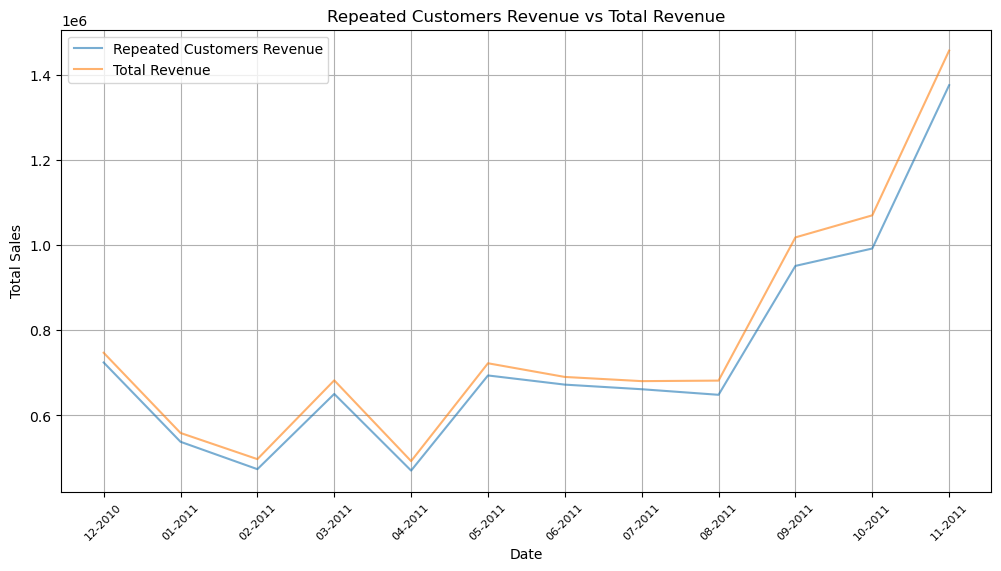

In [48]:
ax = pd.DataFrame(repeated_customers_revenue.values).plot(figsize=(12,6),
                                            alpha=0.6,
                                            grid=True )

pd.DataFrame(total_customers_revenue.values).plot(ax=ax,
                                    alpha=0.6,
                                    grid=True )
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(['Repeated Customers Revenue', 'Total Revenue'])
ax.set_title('Repeated Customers Revenue vs Total Revenue')
ax.set_xticks(range(len(repeated_customers_revenue.index)), [x.strftime('%m-%Y') for x in repeated_customers_revenue.index], rotation=45, fontsize=8)


plt.show()

* The same pattern is noticed; there is a significant increase in sales starting **SEP-2011**.
* We can notice that almost all revenue is generated from repeated customers, this reflects an overall positive customer experience.